In [114]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

# Step 1: Problem Definition
In this project, we aim to implement and evaluate several machine learning classification algorithms using the well-known Iris flower dataset. The primary objectives of this study are as follows:
- **Objective:** To classify iris flowers into their three respective species (**Setosa**, **Versicolor**, and **Virginica**) based on four specific physical features: **sepal length**, **sepal width**, **petal length**, and **petal width**.
- **Outcome:** By the end of this exercise, we will compare these models to determine which algorithm is most effective for this particular dataset, providing insights into their strengths and weaknesses in a multiclass classification context.

# Step 2: Data Collection
In this phase, we import the Iris dataset from the scikit-learn library. This dataset is a classic benchmark in machine learning, containing 150 samples of iris flowers.

**Data Details:**
- **Source:** sklearn.datasets.load_iris
- **Features:** Four numerical measurements (sepal length, sepal width, petal length, and petal width in cm).
- **Target:** Three classes representing species of the iris flower.

In [115]:
# Load the Iris dataset
iris = load_iris()
X = iris.data  # Feature matrix
y = iris.target  # Target vector

# Reporting Statistics
print("--- Dataset Statistics ---")
print(f"Total number of samples: {X.shape[0]}")
print(f"Total number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class labels: {iris.target_names}")

--- Dataset Statistics ---
Total number of samples: 150
Total number of features: 4
Number of classes: 3
Class labels: ['setosa' 'versicolor' 'virginica']


In [116]:
# Preview the data structure

df = pd.DataFrame(data=X, columns=iris.feature_names)
df['species'] = y

df.info()
df.describe()

cat_col = df.select_dtypes(include=['object', 'category']).columns
num_col = df.select_dtypes(include=['number']).columns
print('Categorical columns:', list(cat_col))
print('Numerical columns:', list(num_col))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
Categorical columns: []
Numerical columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']


In [117]:
df.head(n=20)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


# Step 3: Data Cleaning and Preprocessing
The Iris dataset is already well-structured, containing **no missing values or extreme outliers**. However, to ensure a robust evaluation, we must:
- Check for **missing** and **duplicate** values
- **Split the Data:** Divide the dataset into Training and Testing sets. This is a vital step to avoid overfitting and to assess how well our models perform on unseen, new data.
- **Strategy:** We will use a 80/20 split (80% for training, 20% for testing), which is standard practice to maintain enough data for both learning and validation.
- **Scaling:** While some algorithms (like Decision Trees) are scale-invariant, others (like KNN and SVM) are distance-based and require feature scaling to prevent features with larger ranges from dominating the model.
  - So we will do the scaling in the next steps.


> A duplicate observation was identified during data quality checks.
The duplicate row was removed to avoid potential bias during training.

In [118]:
# 1. Verification of Data Quality

# Check for nulls or missing values
print(f"Missing values: {df.isnull().sum().sum()}")
# Show as percentage
print(round((df.isnull().sum() / df.shape[0]) * 100, 2))
print("-"*50)

# Checking Duplicates
print("Duplicates Report:")
print(df.duplicated().value_counts())
print("-"*50)

# Show Duplicates
print("Show Duplicates:")
# df[df.duplicated()]
duplicate_rows = df[df.duplicated(keep=False)]
print(duplicate_rows)
print("-"*50)

# Remove Duplicates
print("Remove Duplicate:")
df = df.drop_duplicates()
print(df.shape)

# Recreate X and y
X = df.drop('species', axis=1) # axis=1 means: Column
y = df['species']

Missing values: 0
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
species              0.0
dtype: float64
--------------------------------------------------
Duplicates Report:
False    149
True       1
Name: count, dtype: int64
--------------------------------------------------
Show Duplicates:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
101                5.8               2.7                5.1               1.9   
142                5.8               2.7                5.1               1.9   

     species  
101        2  
142        2  
--------------------------------------------------
Remove Duplicate:
(149, 5)


In [119]:
# 2. Splitting the data
# We set random_state=42 to ensure our results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Data splitting complete.")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Data splitting complete.
Training samples: 119
Testing samples: 30


# Step 4: Exploratory Data Analysis (EDA)
EDA allows us to identify patterns, correlations, and potential challenges in the dataset before training our models. For the Iris dataset, we will focus on:
1. **Statistical Distribution:** Understanding the range and distribution of each feature.
2. **Correlation Matrix:** Identifying how strongly features are related to each other.
3. **Visual Patterns:** Using pair-plots to visualize how well the classes are separated in 2D space.


The main goals of EDA are:
- To verify that the dataset is clean and well-structured
- To understand the statistical properties of the features
- To identify patterns that can help with model selection
- To visualize how well the classes are separated
- To detect whether feature scaling may be useful later in the pipeline
- To detect outliers


### EDA Summary

From the exploratory analysis, we can conclude that:

- The dataset is clean and well-structured.
- There are no missing values.
- One duplicate row was found and removed.
- The classes are balanced.
- Petal length and petal width are the most informative features.
- Setosa is easy to separate from the other classes.
- Versicolor and Virginica overlap partially, which may challenge some models.

Overall, this EDA suggests that the Iris dataset is highly suitable for classification and that petal-based features will likely play the most important role in model performance.



## 4.1 Data Overview
Before analyzing the data in depth, we first check the basic structure of the dataset, including:
- number of rows and columns
- data types
- first few samples

This helps confirm that the dataset has been loaded correctly.

### Conclusion

- The dataset is small, clean, and structured.  
- It contains numerical features only, which makes it suitable for classical machine learning algorithms.

In [120]:
# Display basic structure information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)
print("\nData types and non-null counts:")
df.info()

# Display first few rows
df.head()

Dataset shape: (149, 5)

Column names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  149 non-null    float64
 1   sepal width (cm)   149 non-null    float64
 2   petal length (cm)  149 non-null    float64
 3   petal width (cm)   149 non-null    float64
 4   species            149 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 4.2 Data Quality Check

A good EDA process always begins with data quality verification.

Here we check:
- missing values
- duplicate rows

This helps us confirm whether any cleaning is still needed before training models.

### Conclusion

- The Iris dataset contains no missing values.  
- A duplicate row was found and removed before in "Step 3: Data Cleaning and Preprocessing"

In [121]:
# Missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().value_counts())

print("\nDuplicate rows shown explicitly:")
duplicate_rows = df[df.duplicated(keep=False)]
print(duplicate_rows)

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Total missing values:
0

Duplicate rows:
False    149
Name: count, dtype: int64

Duplicate rows shown explicitly:
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), species]
Index: []


## 4.3 Remove Duplicate Rows
> **I've done this step before, let's go through it and comment the code.**

Since one duplicate row was identified, we remove it to keep the dataset consistent.
After cleaning, we recreate the feature matrix and target vector.

```
# Remove duplicates
df = df.drop_duplicates()
# Recreate X and y after cleaning
X = df.drop('species', axis=1)
y = df['species']
print("New dataset shape after duplicate removal:", df.shape)
```

### Conclusion
- After removing the duplicate row, the dataset contains 149 samples.  
- This is the cleaned version that should be used for the rest of the workflow.

## 4.4 Descriptive Statistics

Descriptive statistics help us understand the central tendency, spread, and range of each feature.

We use summary statistics such as:
- count
- mean
- standard deviation
- minimum and maximum values
- quartiles

### Conclusion
- The descriptive statistics show that the Iris features are numerical and have different value ranges.  
- This is one reason why feature scaling may be useful for some models later, especially distance-based algorithms.

In [122]:
# Descriptive statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631,0.993289
std,0.830851,0.436342,1.767791,0.762622,0.817847
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.300000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 4.5 Class Distribution
We now check how many samples belong to each species.
This is important to determine whether the dataset is balanced or imbalanced.

### Conclusion
- The dataset is balanced across the three classes.  
- This is ideal for classification because the model will not be biased toward one class.

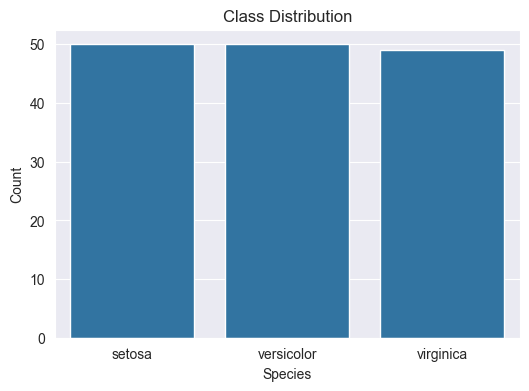

species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64


In [123]:
# Create a readable species name column
species_map = {0: "setosa", 1: "versicolor", 2: "virginica"}
df['species'] = df['species'].map(species_map)

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='species')
plt.title("Class Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# Print value counts
print(df['species'].value_counts())

## 4.6 Statistical Summary by Class

To better understand how the classes differ, we calculate the average value of each feature for every species.

This helps us identify which features are most useful for classification.

### Conclusion

- The class-wise summary shows that petal-related features are usually more informative than sepal-related features.  
- This suggests that petal length and petal width may be stronger predictors of species.

In [124]:
# Group by species and calculate mean values
class_summary = df.groupby('species').mean(numeric_only=True)
class_summary

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006000,3.428000,1.462000,0.246000
versicolor,5.936000,2.770000,4.260000,1.326000
virginica,6.604082,2.979592,5.561224,2.028571


## 4.7 Distribution of Each Feature

We now visualize the distribution of each numerical feature.

This helps us understand:
- how values are spread
- whether distributions overlap across classes
- whether some features separate the species better than others

### Conclusion
- The histograms show that the features are not all distributed in the same way.  
- Some features appear to separate species more clearly than others, especially the petal measurements.

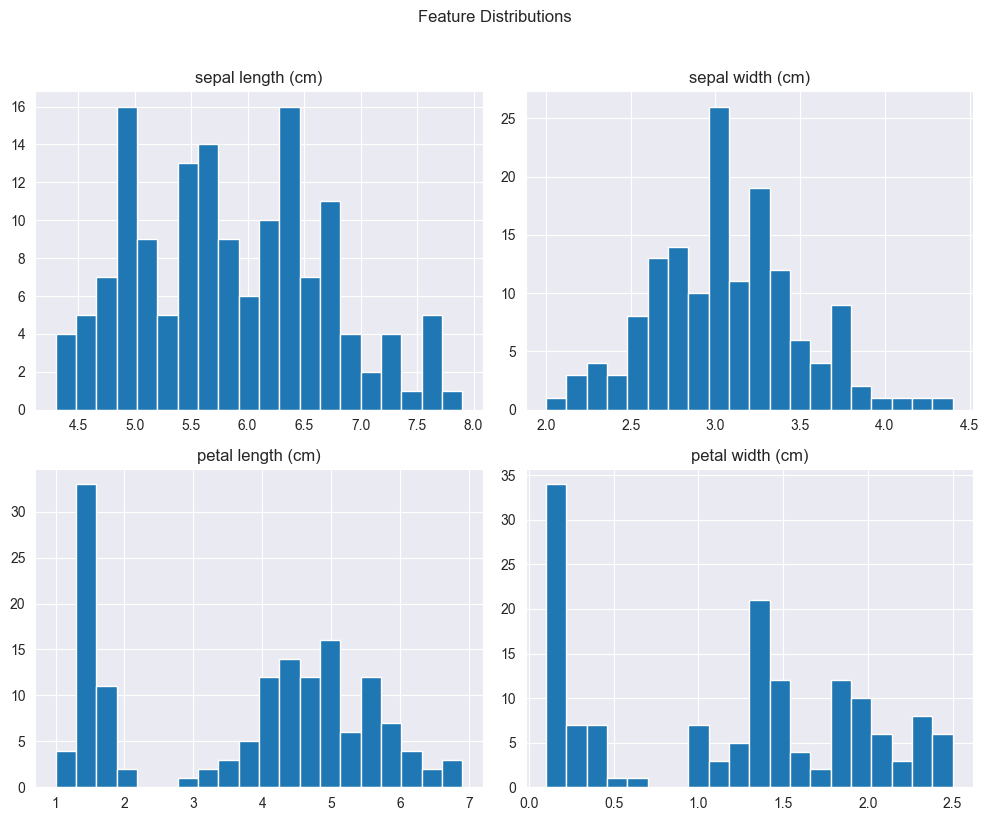

In [125]:
# Histogram plots for each feature
df.drop(columns=['species']).hist(figsize=(10, 8), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

## 4.8 Boxplots by Class

Boxplots help us compare the distribution of each feature across the different species.

They are useful for identifying:
- median values
- spread
- potential outliers
- overlap between classes

### Conclusion
- The boxplots clearly show that Setosa is well separated from the other two classes.  
- Versicolor and Virginica overlap more, which may make classification slightly harder for some models.

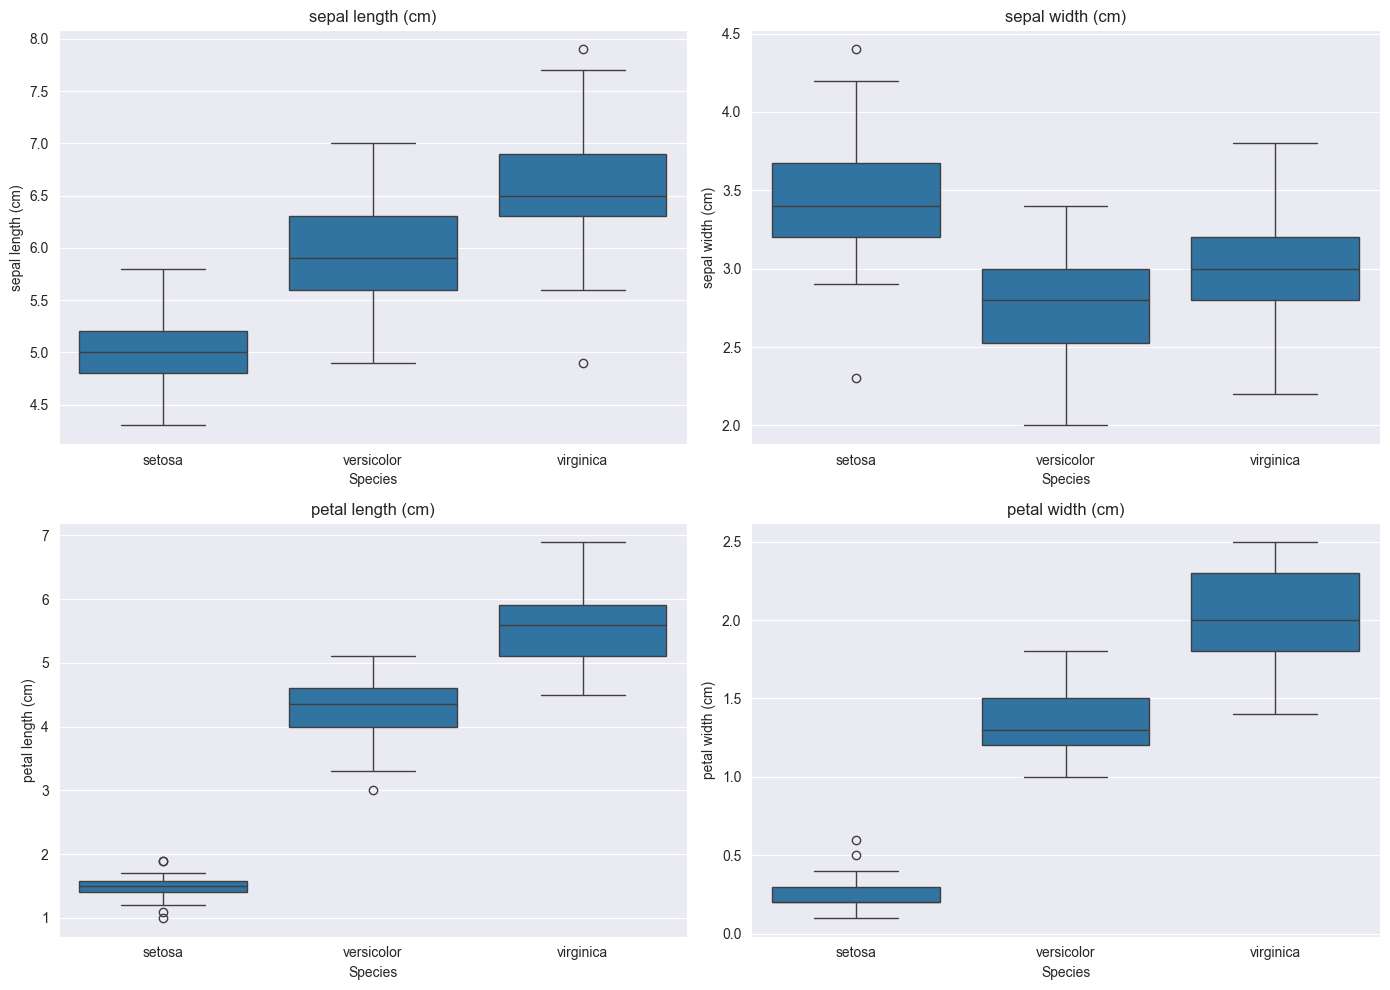

In [126]:
# Boxplots for each feature by species
features = iris.feature_names

plt.figure(figsize=(14, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='species', y=feature)
    plt.title(feature)
    plt.xlabel("Species")
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

## 4.9 Correlation Matrix

Correlation analysis helps us understand how strongly the features are related to one another.

This is especially useful for:
- feature interpretation
- identifying redundant variables
- understanding whether some features move together

### Conclusion
- The correlation heatmap shows that petal length and petal width are strongly related.  
- This indicates that these two features may carry similar information and are likely important for classification.

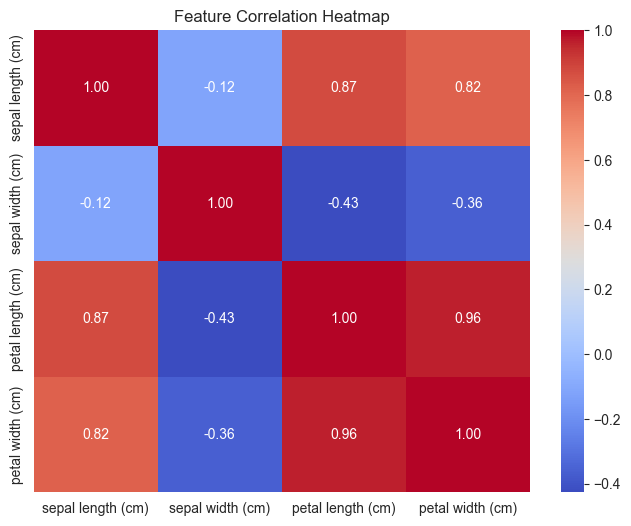

In [127]:
# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## 4.10 Pairplot

The pairplot is one of the most useful visual tools for the Iris dataset.

It shows:
- the distribution of each feature
- the relationship between every pair of features
- how well the classes are separated in 2D space

### Conclusion
- The pairplot shows that Setosa is almost completely separable from the other species.  
- Versicolor and Virginica overlap in some areas, which explains why some classification models may find them more difficult to distinguish.

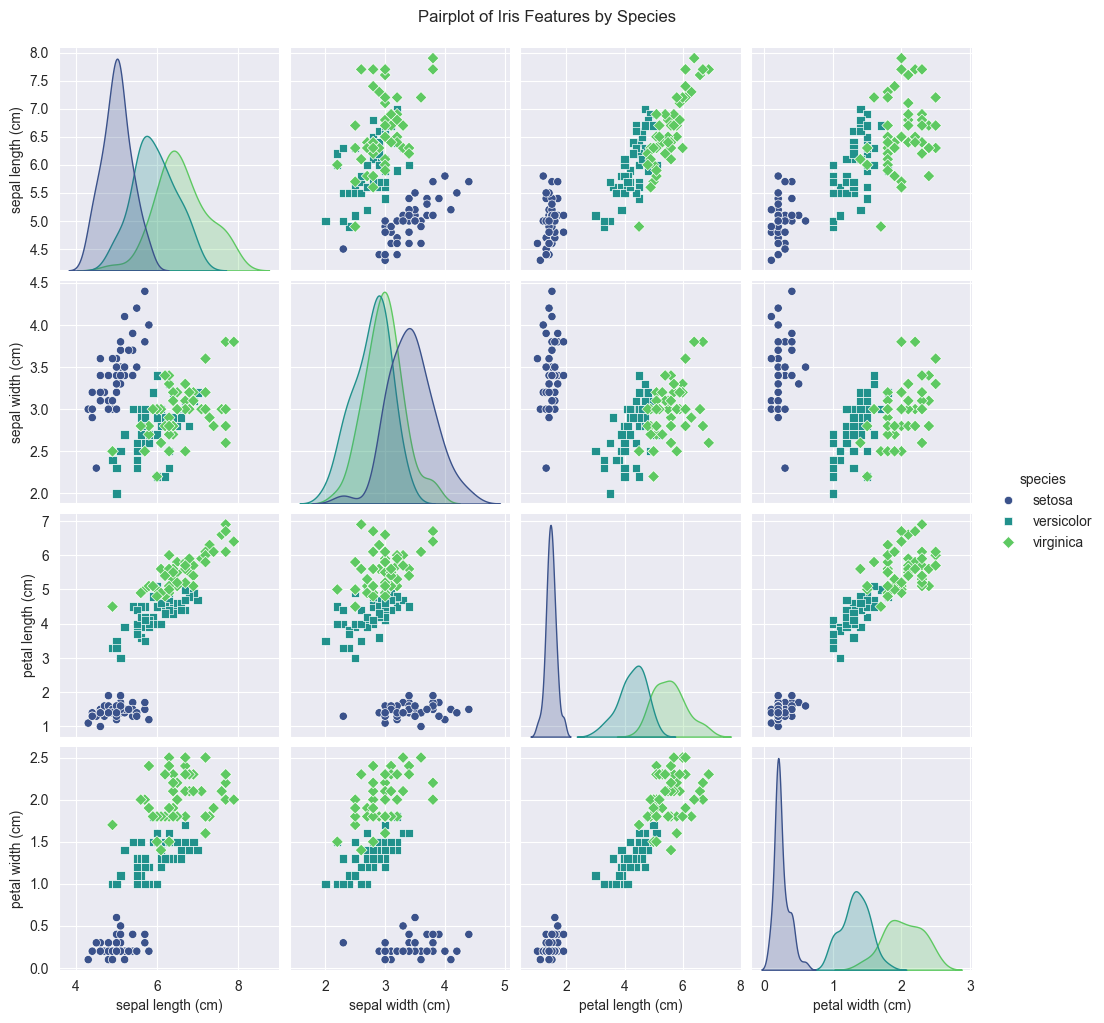

In [128]:
# Pairplot
sns.pairplot(df, hue='species', palette='viridis', markers=["o", "s", "D"])
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

## 4.11 Scatter Plot Example

To better visualize class separation, we can also inspect selected feature pairs directly.
Here we compare petal length and petal width, which are often the most informative features in the Iris dataset.


### Conclusion

- This scatter plot confirms that petal features provide strong class separation.  
- Setosa is clearly distinct, while Versicolor and Virginica still show partial overlap.

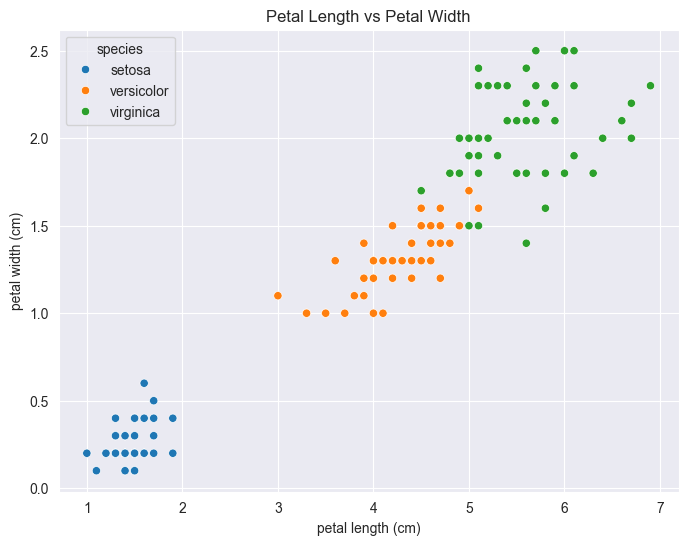

In [129]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species'
)
plt.title("Petal Length vs Petal Width")
plt.show()


## 4.12 Violin Plot Analysis

Violin plots(It's exactly like a violin. lol) help us compare the distribution of each feature across the three species.

They combine the information of a boxplot and a density plot, which makes them useful for understanding:
- distribution shape
- spread
- median values
- overlap between classes

### Conclusion
The violin plots confirm that the petal features are much more discriminative than the sepal features.
- **Setosa** has a very distinct distribution, especially for petal measurements.
- **Versicolor** and **Virginica** overlap more in sepal features.
- The petal distributions show clearer separation, which makes them especially valuable for model training.

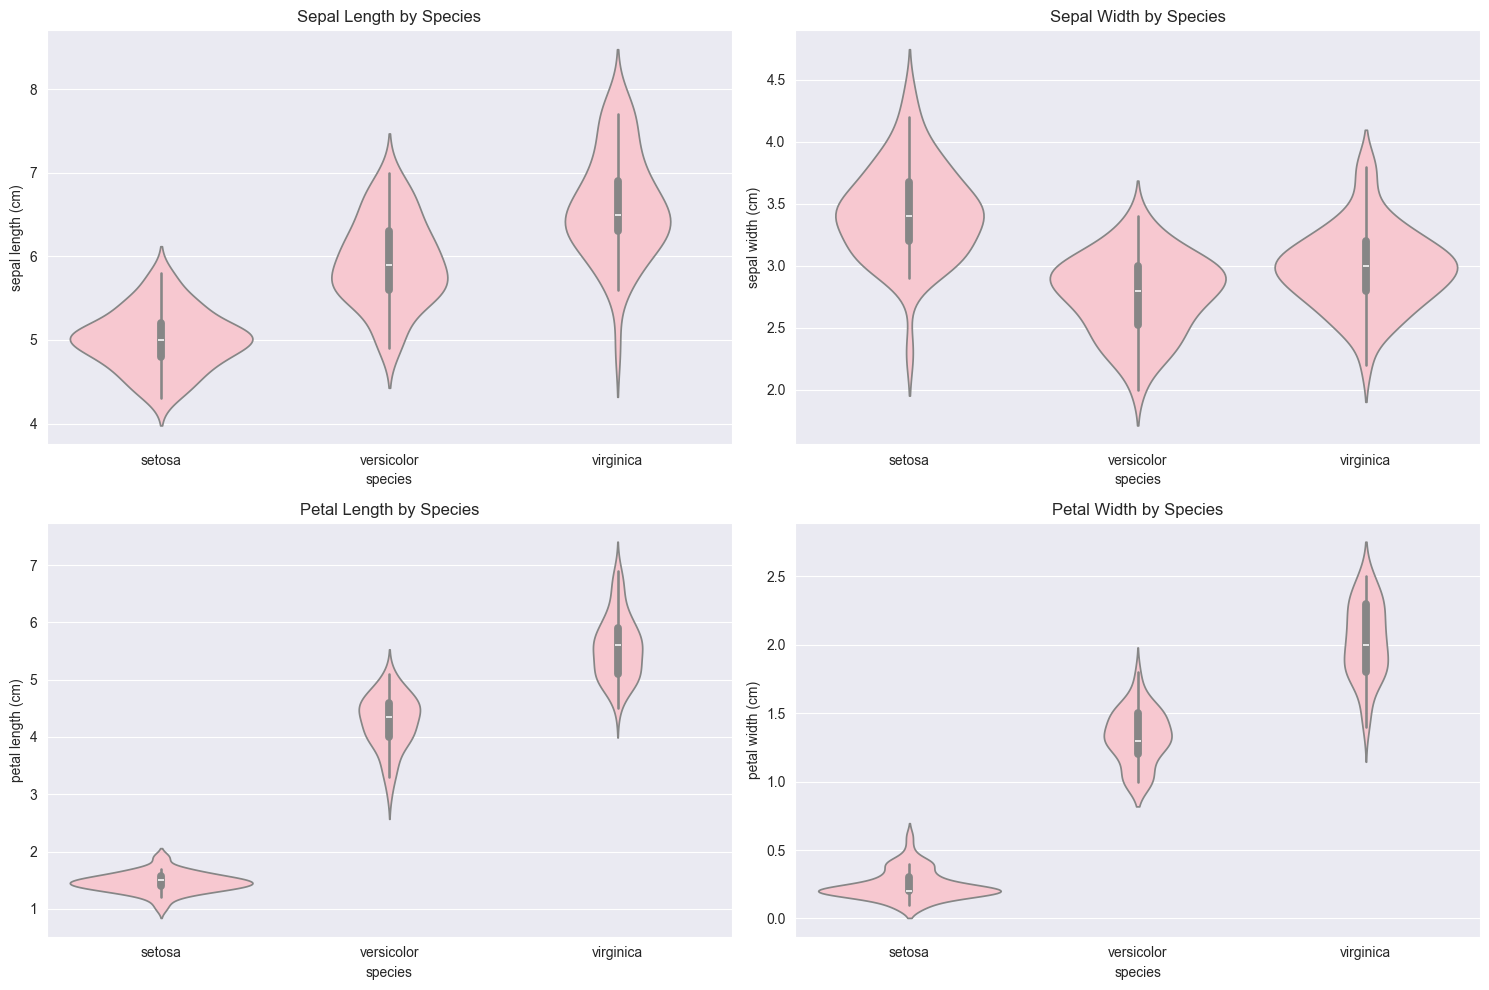

In [130]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.violinplot(x='species', y='sepal length (cm)', data=df, color="pink")
plt.title("Sepal Length by Species")

plt.subplot(2, 2, 2)
sns.violinplot(x='species', y='sepal width (cm)', data=df, color="pink")
plt.title("Sepal Width by Species")

plt.subplot(2, 2, 3)
sns.violinplot(x='species', y='petal length (cm)', data=df, color="pink")
plt.title("Petal Length by Species")

plt.subplot(2, 2, 4)
sns.violinplot(x='species', y='petal width (cm)', data=df, color="pink")
plt.title("Petal Width by Species")

plt.tight_layout()
plt.show()

# Step 5: Feature Engineering and Selection
In this step, we explore whether we can improve the predictive power of the Iris dataset by creating a few meaningful derived features and identifying the most informative variables.

While the Iris dataset features are already well-defined, in a professional workflow, this stage is crucial for:
1. **Feature Engineering:** Creating new variables that might better represent the underlying patterns.
2. **Feature Selection:** Determining which features contribute most to the model's predictive power.

In this specific case, we will use a **Random Forest Classifier** as a heuristic tool to calculate "Feature Importance." This helps us understand which physical measurements (sepal/petal length and width) are the primary drivers in classifying the iris species.

### Step 5 Summary

In this step, we:
- created a few engineered features for educational purposes,
- inspected their statistical properties,
- evaluated their importance using Random Forest,
- evaluated them again using mutual information,
- and selected the most informative subset for comparison. (HAHA Just For Fun And Learning)

For the Iris dataset, feature engineering is not strictly necessary for the final model. The original features are already strong enough for classification. However, this step is still valuable because it demonstrates how domain knowledge can be used to create additional variables and how to test whether they are actually helpful.

## 5.1 Create Engineered Features
> **These codes (feature engineering scope) is for further learning only and is a demonstration of feature engineering and will not be used in practice
(ML Model).**

Although the original Iris dataset is already strong, we can still create a few additional features to demonstrate feature engineering.

Based on domain knowledge, the following derived features are often useful:
- **Sepal Area** = sepal length × sepal width
- **Petal Area** = petal length × petal width
- **Sepal Length / Sepal Width Ratio**
- **Petal Length / Petal Width Ratio**

These features can reveal patterns that are not directly visible in the raw measurements.

### Conclusion
- We created four additional features using simple mathematical transformations.
- These features are not required for the final model, but they are useful for learning how feature engineering works and how domain knowledge can be converted into numerical variables.

In [131]:
# Work on a copy to keep the original dataframe unchanged
df_fe_temp = df.copy()

# Create engineered features
df_fe_temp['sepal area (cm^2)'] = df_fe_temp['sepal length (cm)'] * df_fe_temp['sepal width (cm)']
df_fe_temp['petal area (cm^2)'] = df_fe_temp['petal length (cm)'] * df_fe_temp['petal width (cm)']

df_fe_temp['sepal length to width ratio'] = df_fe_temp['sepal length (cm)'] / df_fe_temp['sepal width (cm)']
df_fe_temp['petal length to width ratio'] = df_fe_temp['petal length (cm)'] / df_fe_temp['petal width (cm)']

# Display the updated dataframe structure
print("New dataset shape after feature engineering:", df_fe_temp.shape)
df_fe_temp.head()

New dataset shape after feature engineering: (149, 9)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,sepal area (cm^2),petal area (cm^2),sepal length to width ratio,petal length to width ratio
0,5.1,3.5,1.4,0.2,setosa,17.85,0.28,1.457143,7.0
1,4.9,3.0,1.4,0.2,setosa,14.70,0.28,1.633333,7.0
2,4.7,3.2,1.3,0.2,setosa,15.04,0.26,1.468750,6.5
3,4.6,3.1,1.5,0.2,setosa,14.26,0.30,1.483871,7.5
4,5.0,3.6,1.4,0.2,setosa,18.00,0.28,1.388889,7.0


## 5.2 Compare Original and Engineered Features

Before selecting features, it is useful to inspect the summary statistics of the new dataset.

This helps us check whether the engineered features produce reasonable numeric values and whether they might contain useful information.

### Conclusion
- The engineered features have valid numerical ranges.
- At this stage, we do not yet know whether they improve model performance, so the next step is to evaluate their importance.

In [132]:
df_fe_temp.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),sepal area (cm^2),petal area (cm^2),sepal length to width ratio,petal length to width ratio
count,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631,17.837383,5.767919,1.952376,4.321414
std,0.830851,0.436342,1.767791,0.762622,3.368472,4.717353,0.401511,2.494442
min,4.300000,2.000000,1.000000,0.100000,10.000000,0.110000,1.268293,2.125000
25%,5.100000,2.800000,1.600000,0.300000,15.660000,0.420000,1.545455,2.809524
50%,5.800000,3.000000,4.300000,1.300000,17.680000,5.590000,2.031250,3.300000
75%,6.400000,3.300000,5.100000,1.800000,20.400000,9.690000,2.225806,4.666667
max,7.900000,4.400000,6.900000,2.500000,30.020000,15.870000,2.961538,15.000000


## 5.3 Prepare Data for Feature Selection

Now we separate the target variable from the feature set.

For feature selection, we will use only the training data later to avoid data leakage.

### Conclusion
- We split the engineered dataset into training and testing sets before applying feature selection.
- This is important because feature selection methods must be learned from the training set only to prevent leakage from the test set.

In [133]:
# Define features and target
X_fe = df.drop(columns=['species'])
y_fe = df['species']

# Split the engineered dataset before feature analysis
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.2,
    random_state=42,
    stratify=y_fe
)

print("Training samples:", X_train_fe.shape[0])
print("Testing samples:", X_test_fe.shape[0])
print("Number of features:", X_train_fe.shape[1])

Training samples: 119
Testing samples: 30
Number of features: 4


## 5.4 Feature Importance with Random Forest

One useful way to estimate feature relevance is to train a tree-based model and inspect its feature importance scores.

Random Forest is a good choice here because:
- it works well with numerical features,
- it does not require scaling,
- and it gives interpretable importance scores.

### Conclusion
- The Random Forest scores help us identify which original or engineered features are most useful.
- In the Iris dataset, petal-related features usually remain the most informative.

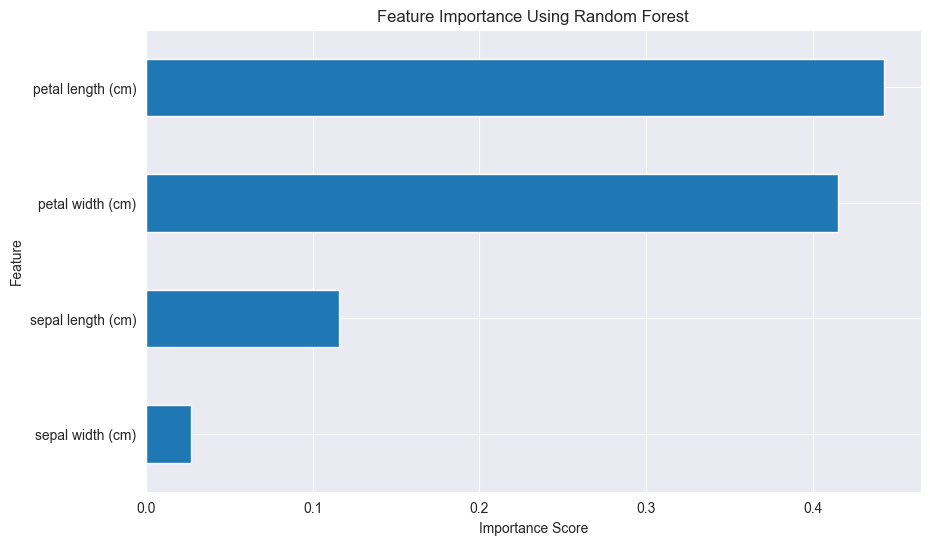

Feature Importance Scores:
petal length (cm)    0.442441
petal width (cm)     0.414650
sepal length (cm)    0.115563
sepal width (cm)     0.027346
dtype: float64


In [134]:
# Train Random Forest on the training set only
rf_selector = RandomForestClassifier(n_estimators=200, random_state=42)
rf_selector.fit(X_train_fe, y_train_fe)

# Extract feature importances
feature_importances = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_fe.columns
).sort_values(ascending=True)

# Plot feature importances
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh')
plt.title("Feature Importance Using Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

print("Feature Importance Scores:")
print(feature_importances.sort_values(ascending=False))

## 5.5 Mutual Information Feature Analysis

Another useful way to inspect feature relevance is mutual information.

This method measures how much information each feature provides about the target variable.

It is helpful because it can capture both linear and non-linear relationships.

### Conclusion
- Mutual information gives us another perspective on feature usefulness.
- If the engineered features rank highly, they may be worth keeping for experimentation. If not, the original features may already be sufficient.

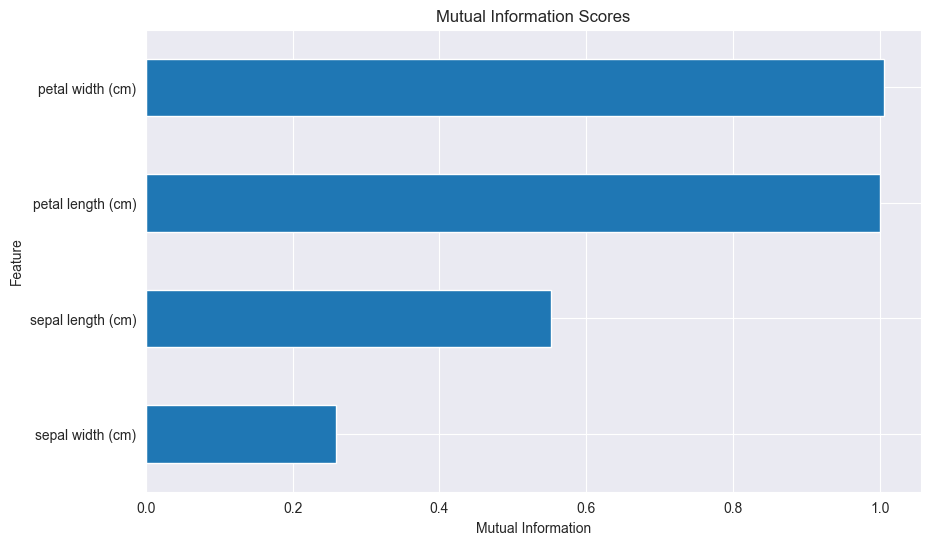

Mutual Information Scores:
petal width (cm)     1.005330
petal length (cm)    1.000550
sepal length (cm)    0.551755
sepal width (cm)     0.259564
dtype: float64


In [135]:
# Compute mutual information scores
mi_scores = mutual_info_classif(X_train_fe, y_train_fe, random_state=42)

mi_df = pd.Series(mi_scores, index=X_train_fe.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
mi_df.plot(kind='barh')
plt.title("Mutual Information Scores")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.show()

print("Mutual Information Scores:")
print(mi_df.sort_values(ascending=False))

## 5.6 Select the Most Informative Features

Now we can choose a subset of the most informative features for comparison.

Because this is an educational project, the goal here is not to permanently replace the original dataset, but to see whether engineered features improve the analysis.

### Conclusion
- The selected features represent the most informative variables according to Random Forest.
- This gives us a compact feature subset that we can compare with the original feature set later during model training.

In [136]:
# Choose top features based on Random Forest importance
top_n = 4
selected_features = feature_importances.sort_values(ascending=False).head(top_n).index.tolist()

print("Selected features based on Random Forest:")
print(selected_features)

# Create reduced datasets
X_train_selected = X_train_fe[selected_features]
X_test_selected = X_test_fe[selected_features]

print("\nShape of selected training set:", X_train_selected.shape)
print("Shape of selected testing set:", X_test_selected.shape)

Selected features based on Random Forest:
['petal length (cm)', 'petal width (cm)', 'sepal length (cm)', 'sepal width (cm)']

Shape of selected training set: (119, 4)
Shape of selected testing set: (30, 4)


# Step 6: Model Selection

At this stage, the goal is to compare several machine learning models and choose the one that performs best on the Iris classification task.

Model selection is important because:
- some models are simpler and more interpretable,
- some models handle non-linear patterns better,
- some models require feature scaling,
- and different models may give slightly different results on the same dataset.

For the Iris dataset, we will compare a few strong baseline classifiers:
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest

To make the comparison fair, we will evaluate them using:
- **Accuracy**
- **Confusion Matrix**
- **Classification Report**
- **Cross-Validation Accuracy**

> When selecting the final model, do not look only at accuracy.
Also consider:
> - **Interpretability:** Is the model easy to explain?
> - **Performance:** Does it predict well on unseen data?
> - **Stability:** Does it perform consistently across validation folds?
> - **Scalability:** Will it still work well on larger datasets?
> - **Complexity:** Is the model unnecessarily complicated for a simple problem?


### Model Selection Strategy: Proper Evaluation Approach
When working with multiple machine learning models, it is important to understand that comparing models is not just about using default settings. A correct evaluation strategy is typically done in multiple stages.

#### 1. Baseline Comparison
In this step, we train different models using their default hyperparameters and compare their initial performance.

##### Goal:
The main purpose of this step is to get a quick understanding of which types of models work well on the dataset.

##### Key Idea:
We are not trying to find the best model yet — we are only evaluating the general behavior of different model families.

##### Advantages:
- Fast and easy to implement
- Gives a quick overview of model performance
- Helps narrow down candidate models

##### Limitations:
- Not reliable for final model selection
- Results depend heavily on default hyperparameters
- May unfairly favor or disadvantage certain models


##### Interpretation:
At this stage, models are only being compared in a non-optimized state, so results should be treated as preliminary insights rather than final conclusions.


#### 2. Hyperparameter Tuning
After identifying promising models from the baseline comparison, the next step is to optimize each model individually by tuning its hyperparameters.

##### Goal:

To improve each model to its best possible performance before making a final comparison.

##### Key Idea:

Each model has a unique set of hyperparameters that control its behavior. Proper tuning allows us to explore different configurations and find the optimal one.


## 6.2 Train and Compare Multiple Models
Some models, such as Logistic Regression, KNN, and SVM, work better when features are scaled.
For that reason, we will use a pipeline with StandardScaler where needed.

### Explanation
This code compares models in a structured way:

- cross_val_score(...) measures how stable each model is across different validation folds.
- accuracy_score(...) measures final performance on the unseen test set.
- Sorting by test accuracy helps us identify the strongest model.

### Result Interpretation
After running this cell, you will see a table like this:
- CV Accuracy Mean: average validation performance
- CV Accuracy Std: how consistent the model is
- Test Accuracy: performance on the held-out test set

### A good model usually has:
- high accuracy,
- low standard deviation in cross-validation,
- and good generalization on the test set.

In [137]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define candidate models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []

for name, model in models.items():
    # Cross-validation accuracy
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    
    # Test accuracy
    test_acc = accuracy_score(y_test, y_pred)
    
    # CV: Cross-Validation
    results.append({
        "Model": name,
        "CV Accuracy Mean": cv_scores.mean(),
        "CV Accuracy Std": cv_scores.std(),
        "Test Accuracy": test_acc
    })

results_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False)
results_df

,Model,CV Accuracy Mean,CV Accuracy Std,Test Accuracy
0,Logistic Regression,0.957971,0.064554,1.0
1,KNN,0.932609,0.062571,1.0
2,SVM,0.957971,0.045649,1.0
3,Decision Tree,0.923913,0.049745,1.0
4,Random Forest,0.949638,0.048534,1.0


## 6.3 Visualize Model Comparison
A chart makes it easier to compare the models visually.

### Explanation
This bar plot shows which model achieved the highest test accuracy.

### Result Interpretation
- The tallest bar represents the best-performing model on the test set.
- If multiple models are very close, prefer the one that is more stable and easier to interpret.

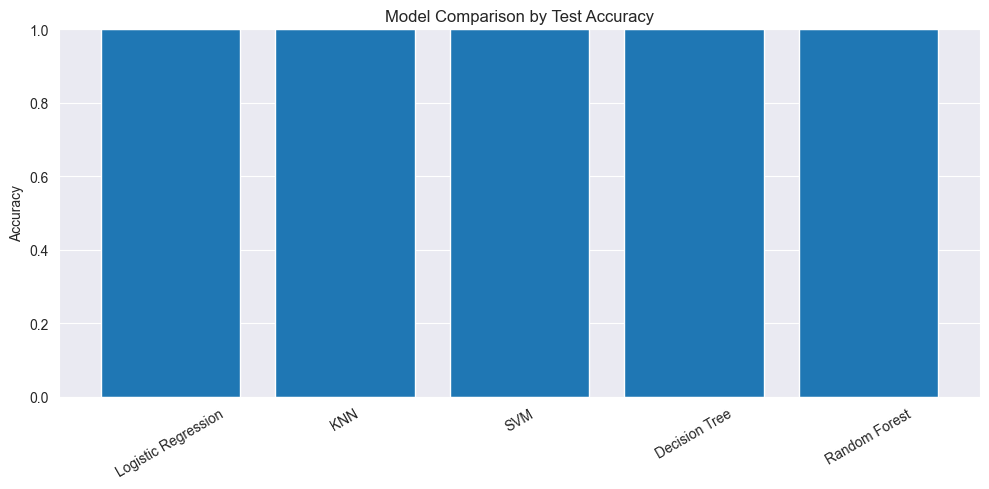

In [138]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.ylim(0, 1)
plt.title("Model Comparison by Test Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6.4 Choose the Best Model
Now we select the best model based on the comparison results.

In [139]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


## 6.5 Evaluate the Best Model in Detail
Accuracy alone is not enough.
We also need to see how the model performs for each class.

### Explanation
This step gives us a deeper evaluation:

- Accuracy tells us the overall correctness.
- Confusion Matrix shows which classes were predicted correctly and which were confused.
- Classification Report includes:
    - precision
    - recall
    - f1-score
    - support

### Result Interpretation
A good confusion matrix should mostly have values along the diagonal, which means the model is predicting the correct class.
For Iris classification, a strong model often achieves:
- very high accuracy,
- very few misclassifications,
- and excellent precision/recall for all species.

In [140]:
# Fit the best model again on the training set
best_model.fit(X_train, y_train)

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
final_accuracy = accuracy_score(y_test, y_pred)
print("Final Test Accuracy:", final_accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Final Test Accuracy: 1.0

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# 6.6 Plot the Confusion Matrix
A heatmap makes the confusion matrix easier to understand.

### Explanation
- Rows represent the true labels.
- Columns represent the predicted labels.
- The diagonal cells show correct predictions.

### Result Interpretation
- Darker diagonal cells mean better performance.
- Off-diagonal values represent classification errors.
- If the off-diagonal values are very small, the model is doing a very good job.

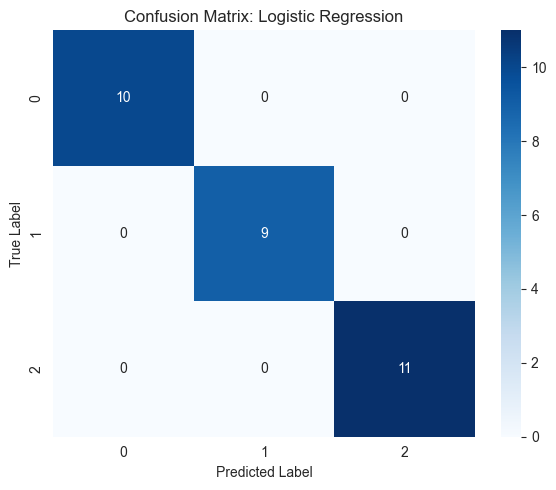

In [141]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()